In [4]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 250 kB 2.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np

BASE = "/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/data/processed/"

imd  = pd.read_excel(BASE + "IMD.xlsx", sheet_name=0)
lsoa = pd.read_csv(BASE + "lsoa.csv")

print("IMD shape:", imd.shape)
print("LSOA shape:", lsoa.shape)

print("\nIMD columns:")
print(imd.columns.tolist())

print("\nLSOA columns:")
print(lsoa.columns.tolist())

IMD shape: (0, 0)
LSOA shape: (35672, 11)

IMD columns:
[]

LSOA columns:
['FID', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area', 'Shape__Length', 'GlobalID']


In [6]:
# Check all sheet names first
import openpyxl
wb = openpyxl.load_workbook(BASE + "IMD.xlsx")
print("Sheet names:", wb.sheetnames)

Sheet names: ['Notes', 'IMD25']


In [7]:
imd = pd.read_excel(BASE + "IMD.xlsx", sheet_name='IMD25')

print("IMD shape:", imd.shape)
print("\nIMD columns:")
print(imd.columns.tolist())
print("\nFirst 5 rows:")
display(imd.head())

IMD shape: (33755, 6)

IMD columns:
['LSOA code (2021)', 'LSOA name (2021)', 'Local Authority District code (2024)', 'Local Authority District name (2024)', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']

First 5 rows:


,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


In [8]:
imd = imd.rename(columns={
    'LSOA code (2021)'                                                        : 'lsoa_code',
    'LSOA name (2021)'                                                        : 'lsoa_name',
    'Local Authority District code (2024)'                                    : 'la_code',
    'Local Authority District name (2024)'                                    : 'la_name',
    'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'    : 'imd_rank',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)': 'imd_decile'
})

print(imd.columns.tolist())
print(imd.shape)
display(imd.head())

['lsoa_code', 'lsoa_name', 'la_code', 'la_name', 'imd_rank', 'imd_decile']
(33755, 6)


,lsoa_code,lsoa_name,la_code,la_name,imd_rank,imd_decile
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10
2,E01000003,City of London 001C,E09000001,City of London,25913,8
3,E01000005,City of London 001E,E09000001,City of London,14807,5
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4


In [9]:
master = pd.read_csv("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/data/processed/master_ped_cyc_urban_2020_2024.csv")

master = master.merge(imd[['lsoa_code', 'imd_rank', 'imd_decile']], 
                      left_on='lsoa_of_accident_location', 
                      right_on='lsoa_code', 
                      how='left')

print(f"Master shape after IMD join: {master.shape}")
print(f"Missing IMD decile: {master['imd_decile'].isnull().sum():,}")
print(master[['lsoa_of_accident_location', 'imd_rank', 'imd_decile']].head(10))

Master shape after IMD join: (141989, 39)
Missing IMD decile: 16,546
  lsoa_of_accident_location  imd_rank  imd_decile
0                 E01003538    5820.0         2.0
1                 E01028156   19843.0         6.0
2                 E01017466    3120.0         1.0
3                 E01009200    1424.0         1.0
4                 E01030190   24250.0         8.0
5                 E01033104    3659.0         2.0
6                 E01009007    2018.0         1.0
7                 E01028175   20562.0         7.0
8                 E01026597      51.0         1.0
9                 E01014489    9802.0         3.0


In [10]:
master = master.dropna(subset=['imd_decile'])

print(f"Rows after dropping missing IMD: {len(master):,}")
print(f"Rows dropped: {141989 - len(master):,}")

master.to_csv("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/data/processed/master_final.csv", index=False)

print("\nSaved: master_final.csv")
print(f"Final shape: {master.shape}")

Rows after dropping missing IMD: 125,443
Rows dropped: 16,546

Saved: master_final.csv
Final shape: (125443, 39)


In [11]:
master = pd.read_csv("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/data/processed/master_final.csv")

print("Shape:", master.shape)
print("\nAll Columns:")
for col in master.columns:
    print(f"  {col}")
    

Shape: (125443, 39)

All Columns:
  collision_index
  collision_ref_no
  vehicle_reference
  casualty_reference
  casualty_class
  sex_of_casualty
  age_of_casualty
  age_band_of_casualty
  casualty_severity
  pedestrian_location
  pedestrian_movement
  car_passenger
  bus_or_coach_passenger
  pedestrian_road_maintenance_worker
  casualty_type
  casualty_imd_decile
  lsoa_of_casualty
  enhanced_casualty_severity
  casualty_injury_based
  casualty_adjusted_severity_serious
  casualty_adjusted_severity_slight
  casualty_distance_banding
  casualty_type_label
  collision_year
  collision_severity
  date
  longitude
  latitude
  urban_or_rural_area
  local_authority_ons_district
  speed_limit
  light_conditions
  weather_conditions
  lsoa_of_accident_location
  escooter_flag
  severity_label
  lsoa_code
  imd_rank
  imd_decile


/var/folders/9y/ymdvgpdn3gd61b94czt9_29m0000gn/T/ipykernel_85683/154328108.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=decile_counts, x='imd_decile', y='casualty_count', palette='RdYlGn')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig1_casualties_by_decile.png'

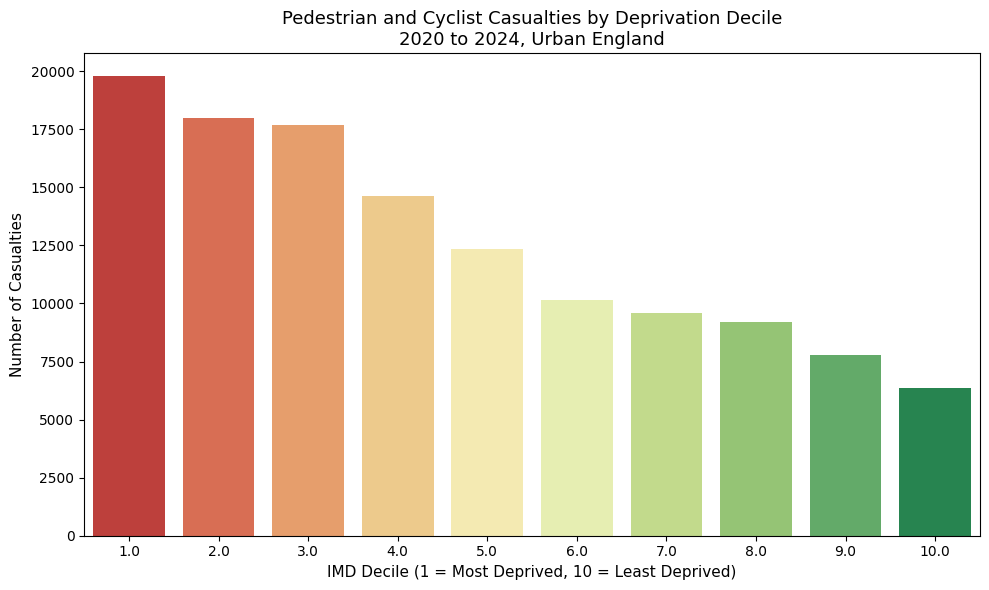

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count casualties per IMD decile
decile_counts = master.groupby('imd_decile').size().reset_index(name='casualty_count')

plt.figure(figsize=(10, 6))
sns.barplot(data=decile_counts, x='imd_decile', y='casualty_count', palette='RdYlGn')

plt.title('Pedestrian and Cyclist Casualties by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
plt.xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
plt.ylabel('Number of Casualties', fontsize=11)
plt.tight_layout()
plt.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig1_casualties_by_decile.png", dpi=150)
plt.show()

print("Saved: fig1_casualties_by_decile.png")
print(decile_counts)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig2_severity_by_decile.png'

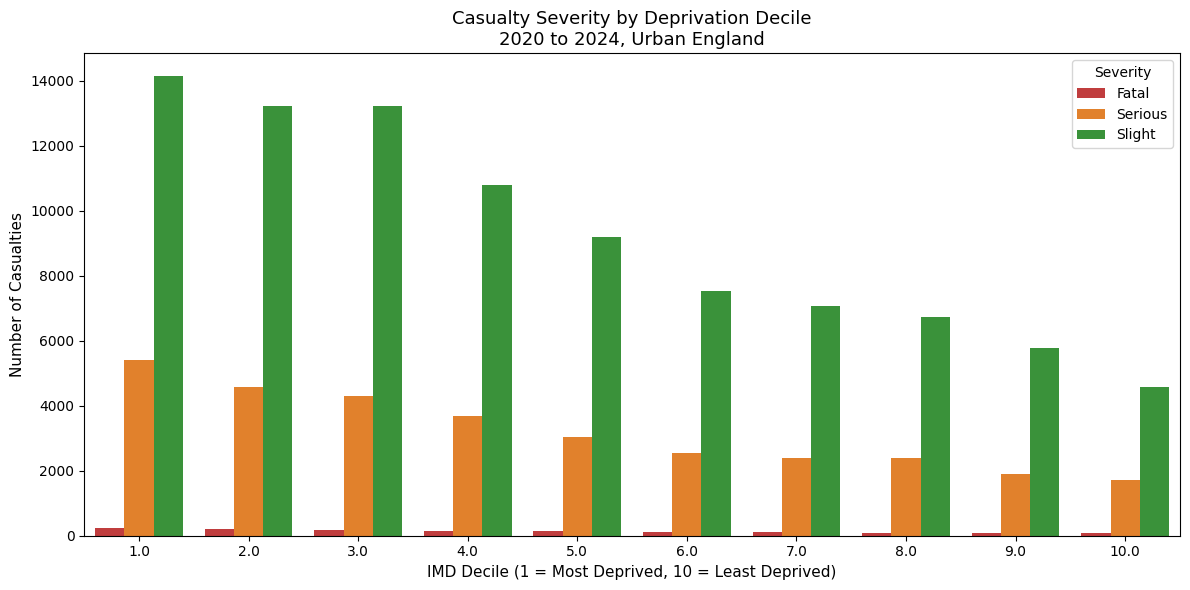

In [13]:
# Count by decile and severity
severity_decile = master.groupby(['imd_decile', 'severity_label']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(data=severity_decile, x='imd_decile', y='count', hue='severity_label',
            palette={'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'})

plt.title('Casualty Severity by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
plt.xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
plt.ylabel('Number of Casualties', fontsize=11)
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig2_severity_by_decile.png", dpi=150)
plt.show()

print("Saved: fig2_severity_by_decile.png")


In [14]:
# Count casualties per LSOA
lsoa_counts = master.groupby('lsoa_of_accident_location').agg(
    casualty_count=('collision_index', 'count'),
    imd_rank=('imd_rank', 'first'),
    imd_decile=('imd_decile', 'first')
).reset_index()

print(f"Unique LSOAs: {len(lsoa_counts):,}")
print(lsoa_counts.head())

Unique LSOAs: 23,412
  lsoa_of_accident_location  casualty_count  imd_rank  imd_decile
0                 E01000001              20   26525.0         8.0
1                 E01000002              11   31203.0        10.0
2                 E01000003               1   25913.0         8.0
3                 E01000005              46   14807.0         5.0
4                 E01000006               3   10917.0         4.0


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig3_scatter_imd_casualties.png'

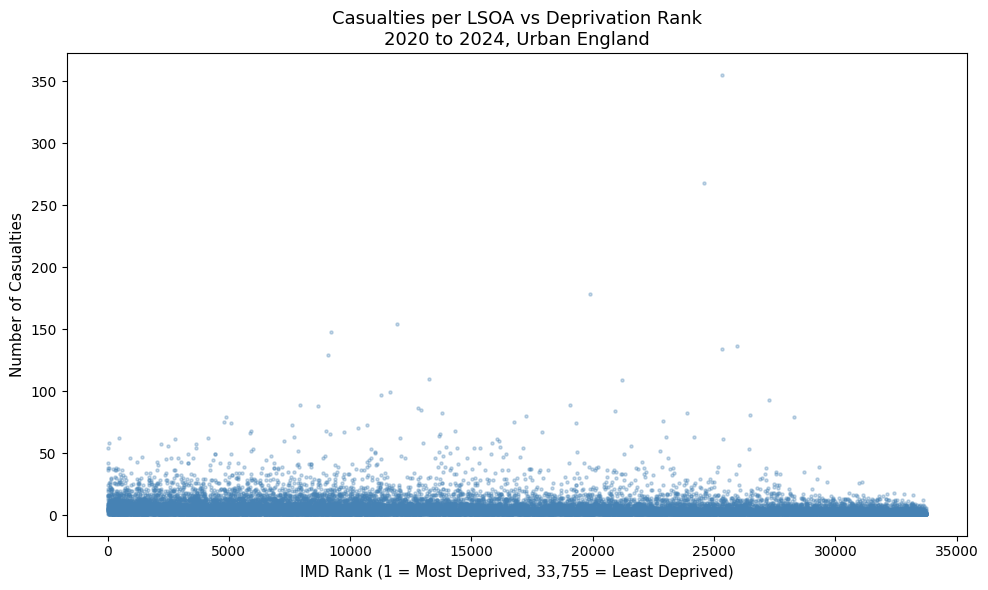

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(lsoa_counts['imd_rank'], lsoa_counts['casualty_count'], 
            alpha=0.3, s=5, color='steelblue')

plt.title('Casualties per LSOA vs Deprivation Rank\n2020 to 2024, Urban England', fontsize=13)
plt.xlabel('IMD Rank (1 = Most Deprived, 33,755 = Least Deprived)', fontsize=11)
plt.ylabel('Number of Casualties', fontsize=11)
plt.tight_layout()
plt.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig3_scatter_imd_casualties.png", dpi=150)
plt.show()

print("Saved: fig3_scatter_imd_casualties.png")

In [16]:
from scipy import stats

corr, pvalue = stats.spearmanr(lsoa_counts['imd_rank'], lsoa_counts['casualty_count'])

print(f"Spearman correlation: {corr:.3f}")
print(f"P-value: {pvalue:.5f}")

if pvalue < 0.05:
    print("Result is statistically significant.")

Spearman correlation: -0.226
P-value: 0.00000
Result is statistically significant.


/var/folders/9y/ymdvgpdn3gd61b94czt9_29m0000gn/T/ipykernel_85683/554185446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=escooter_decile, x='imd_decile', y='casualty_count', palette='RdYlGn')


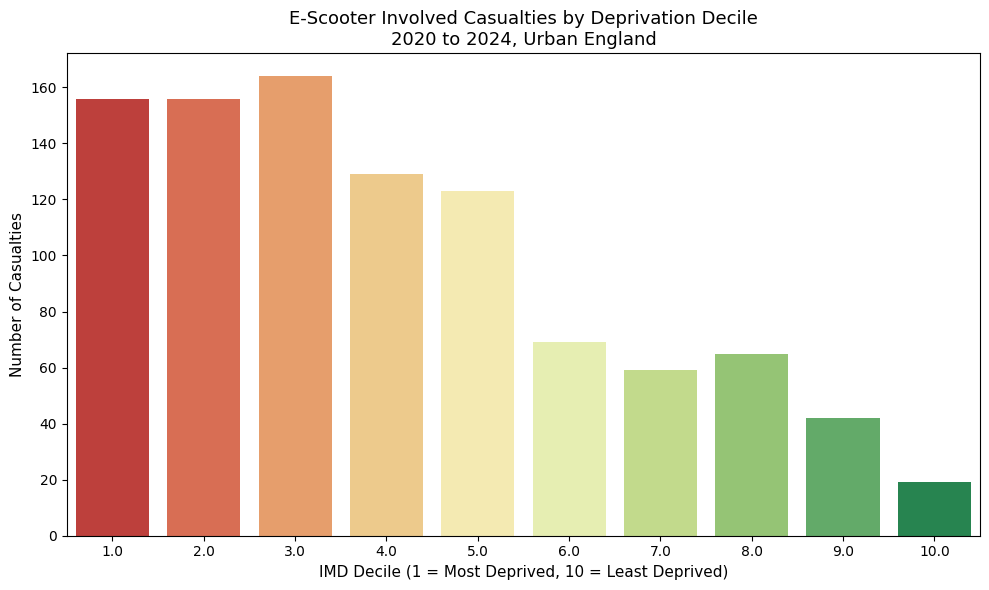

Total e-scooter involved casualties: 982
   imd_decile  casualty_count
0         1.0             156
1         2.0             156
2         3.0             164
3         4.0             129
4         5.0             123
5         6.0              69
6         7.0              59
7         8.0              65
8         9.0              42
9        10.0              19


In [17]:
escooter_only = master[master['escooter_flag'] == 1]

escooter_decile = escooter_only.groupby('imd_decile').size().reset_index(name='casualty_count')

plt.figure(figsize=(10, 6))
sns.barplot(data=escooter_decile, x='imd_decile', y='casualty_count', palette='RdYlGn')

plt.title('E-Scooter Involved Casualties by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
plt.xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
plt.ylabel('Number of Casualties', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Total e-scooter involved casualties: {len(escooter_only):,}")
print(escooter_decile)

In [18]:
pip install geopandas contextily mapclassify

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 323 kB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 59 kB 11.4 MB/s eta 0:00:01
     |████████████████████████████████| 4.9 MB 13.2 MB/s eta 0:00:01
     |████████████████████████████████| 1.3 MB 12.4 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 15.0 MB/s eta 0:00:01
     |████████████████████████████████| 18.8 MB 9.0 MB/s eta 0:00:01
     |████████████████████████████████| 94 kB 7.3 MB/s  eta 0:00:01
     |████████████████████████████████| 125 kB 17.2 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 16.5 MB/s eta 0:00:01
     |████████████████████████████████| 40 kB 4.9 MB/s eta 0:00:01
  Using cached click-8.1.8-py3-none-any.whl (98 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use update

In [20]:
import geopandas as gpd
from shapely.geometry import Point

# Load as regular dataframe first
lsoa_df = pd.read_csv(PROCESSED + "lsoa.csv")

# Create geometry from LAT and LONG
lsoa_gdf = gpd.GeoDataFrame(
    lsoa_df,
    geometry=gpd.points_from_xy(lsoa_df['LONG'], lsoa_df['LAT']),
    crs='EPSG:4326'
)

print("LSOA GDF shape:", lsoa_gdf.shape)
print("CRS:", lsoa_gdf.crs)
print(lsoa_gdf[['LSOA21CD', 'LAT', 'LONG', 'geometry']].head())

LSOA GDF shape: (35672, 12)
CRS: EPSG:4326
    LSOA21CD       LAT      LONG                   geometry
0  E01000001  51.51817 -0.097150  POINT (-0.09715 51.51817)
1  E01000002  51.51883 -0.091970  POINT (-0.09197 51.51883)
2  E01000003  51.52174 -0.095330  POINT (-0.09533 51.52174)
3  E01000005  51.51469 -0.076280  POINT (-0.07628 51.51469)
4  E01000006  51.53875  0.089317   POINT (0.08932 51.53875)


In [21]:
# Aggregate casualties per LSOA
lsoa_counts = master.groupby('lsoa_of_accident_location').agg(
    casualty_count=('collision_index', 'count'),
    imd_decile=('imd_decile', 'first'),
    imd_rank=('imd_rank', 'first'),
    escooter_count=('escooter_flag', 'sum')
).reset_index()

# Merge with LSOA geodataframe
lsoa_gdf = lsoa_gdf.merge(lsoa_counts, 
                           left_on='LSOA21CD', 
                           right_on='lsoa_of_accident_location', 
                           how='left')

# Fill LSOAs with no casualties as 0
lsoa_gdf['casualty_count'] = lsoa_gdf['casualty_count'].fillna(0)

print("Merged GDF shape:", lsoa_gdf.shape)
print(f"LSOAs with casualties: {(lsoa_gdf['casualty_count'] > 0).sum():,}")
print(lsoa_gdf[['LSOA21CD', 'casualty_count', 'imd_decile']].head(10))

Merged GDF shape: (35672, 17)
LSOAs with casualties: 23,412
    LSOA21CD  casualty_count  imd_decile
0  E01000001            20.0         8.0
1  E01000002            11.0        10.0
2  E01000003             1.0         8.0
3  E01000005            46.0         5.0
4  E01000006             3.0         4.0
5  E01000007            11.0         2.0
6  E01000008            11.0         2.0
7  E01000009            21.0         2.0
8  E01000011             2.0         2.0
9  E01000012             6.0         2.0


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig4_casualty_map.png'

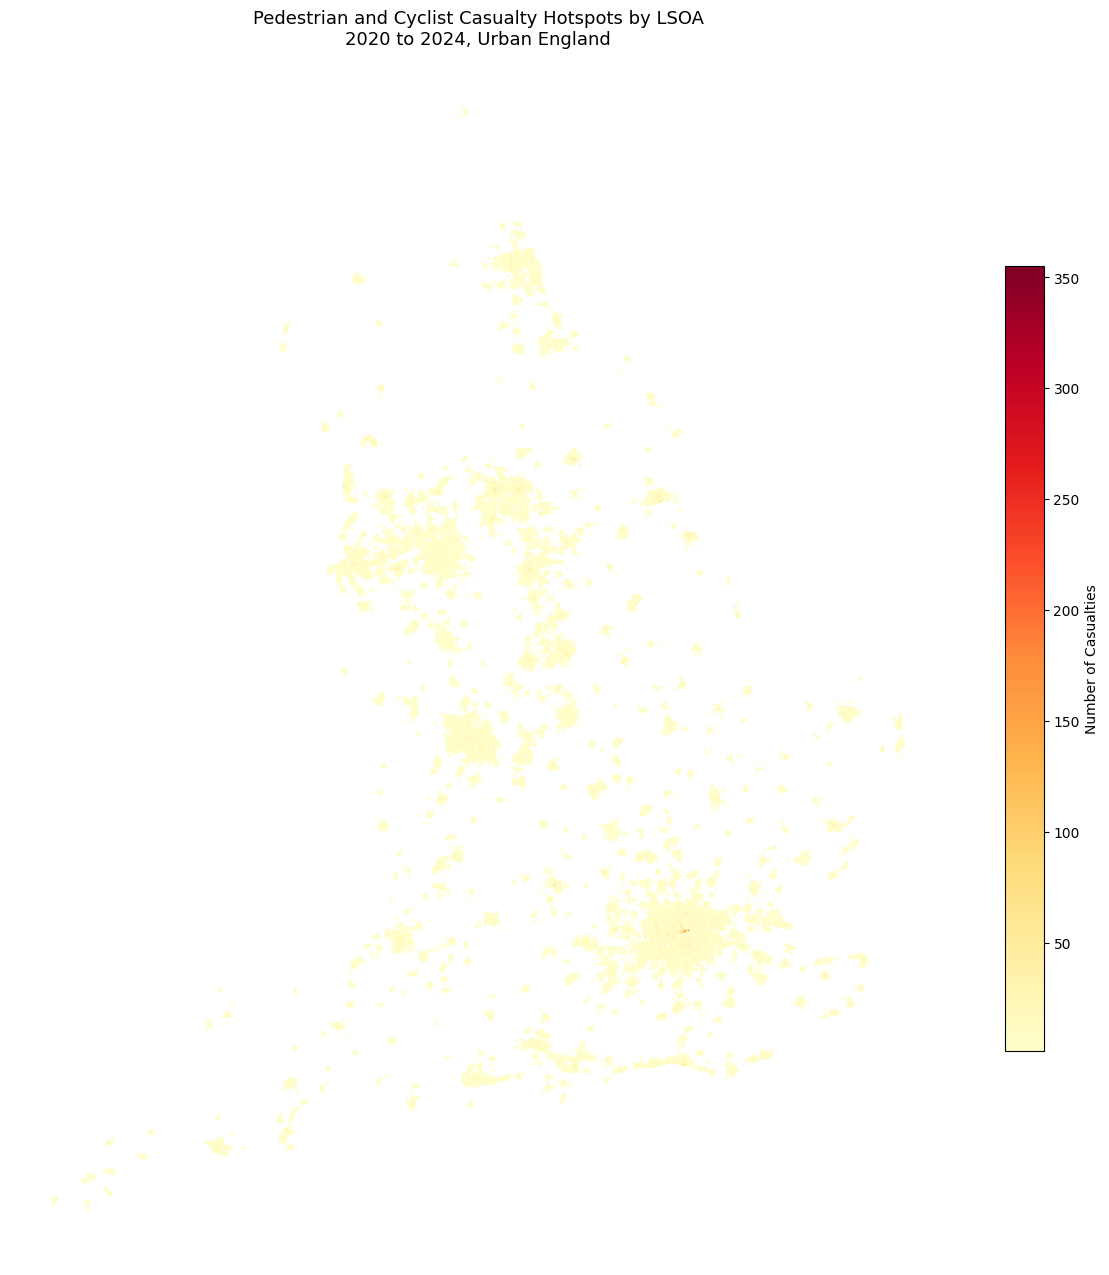

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

# Filter to LSOAs with casualties only
map_data = lsoa_gdf[lsoa_gdf['casualty_count'] > 0].copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 16))

map_data.plot(
    column='casualty_count',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Number of Casualties', 'shrink': 0.5},
    markersize=2,
    alpha=0.7
)

ax.set_title('Pedestrian and Cyclist Casualty Hotspots by LSOA\n2020 to 2024, Urban England', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig4_casualty_map.png", dpi=150)
plt.show()

print("Saved: fig4_casualty_map.png")

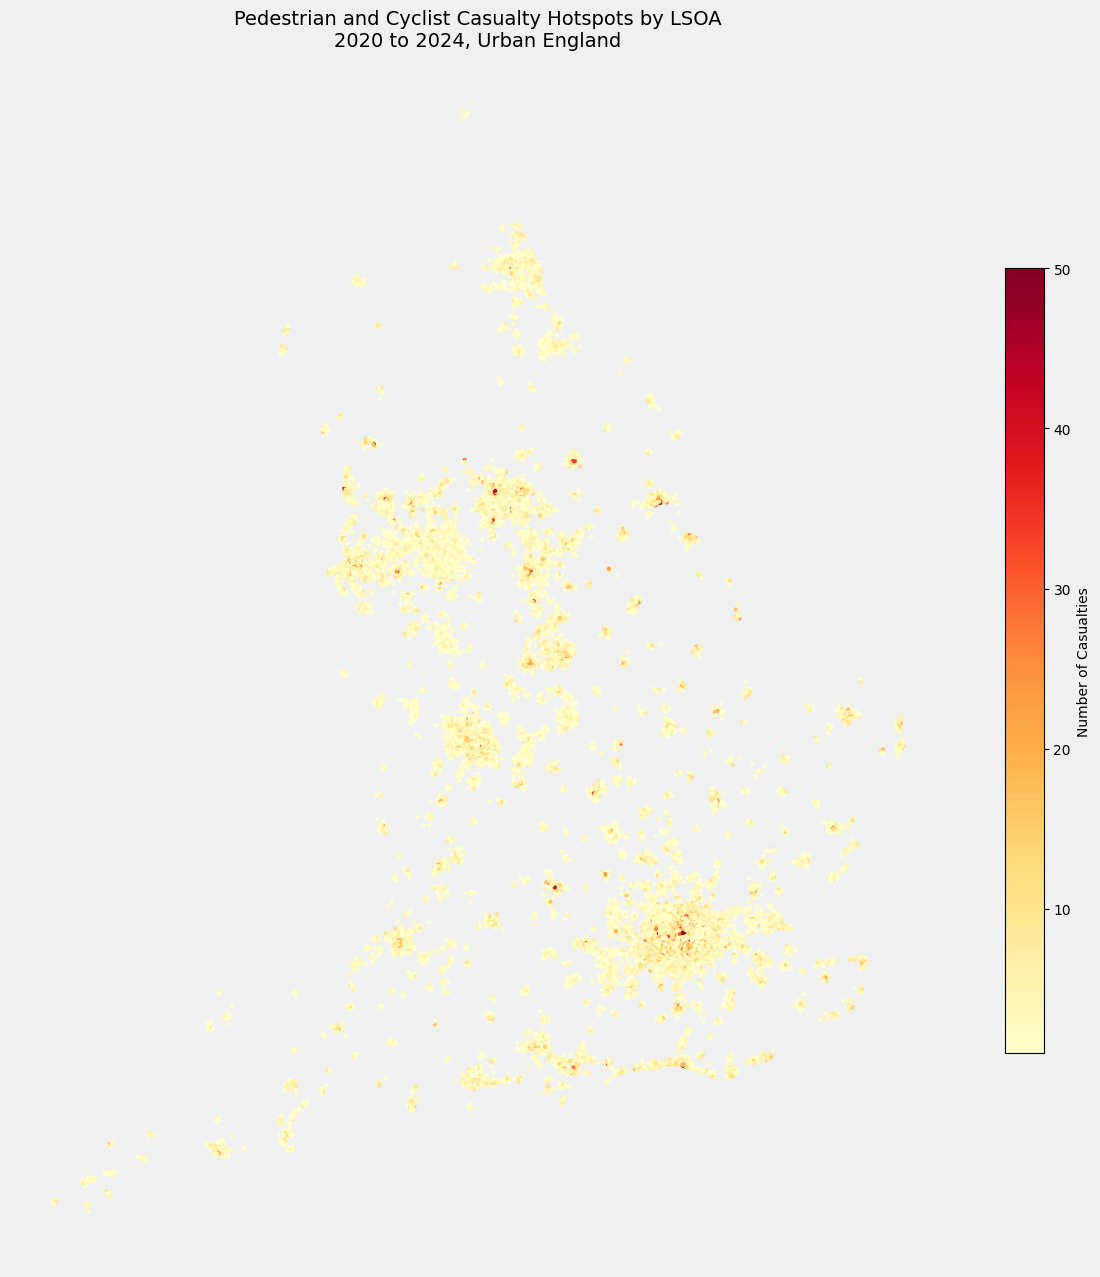

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 16))

map_data = lsoa_gdf[lsoa_gdf['casualty_count'] > 0].copy()

map_data.plot(
    column='casualty_count',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Number of Casualties', 'shrink': 0.5},
    markersize=4,
    alpha=0.8,
    vmin=1,
    vmax=50  # cap at 50 so most LSOAs show colour variation
)

ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#f0f0f0')
ax.set_title('Pedestrian and Cyclist Casualty Hotspots by LSOA\n2020 to 2024, Urban England', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

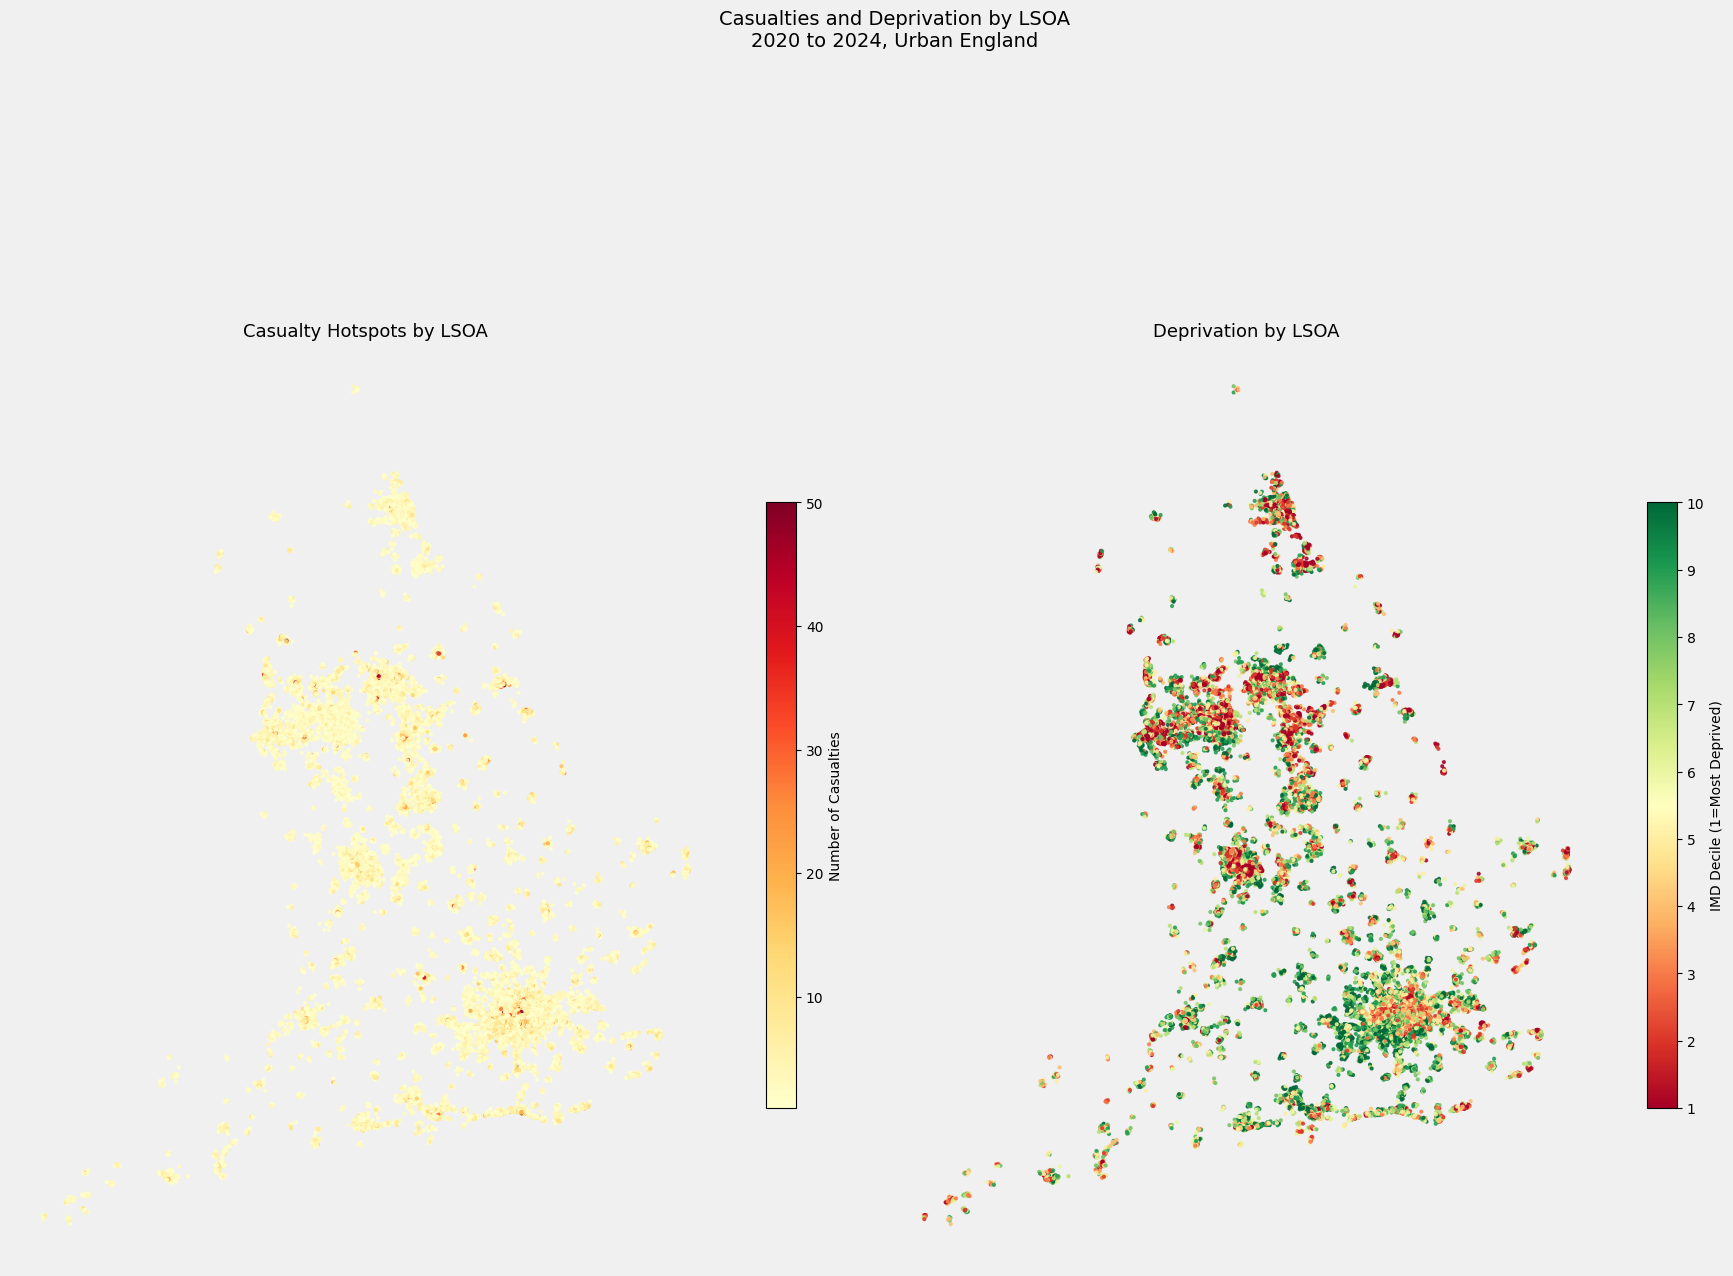

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 16))

# Left map — casualties
map_data.plot(
    column='casualty_count',
    ax=axes[0],
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Number of Casualties', 'shrink': 0.4},
    markersize=4,
    alpha=0.8,
    vmin=1,
    vmax=50
)
axes[0].set_facecolor('#f0f0f0')
axes[0].set_title('Casualty Hotspots by LSOA', fontsize=13)
axes[0].set_axis_off()

# Right map — IMD deprivation
map_data2 = lsoa_gdf[lsoa_gdf['imd_decile'].notna()].copy()
map_data2.plot(
    column='imd_decile',
    ax=axes[1],
    cmap='RdYlGn',
    legend=True,
    legend_kwds={'label': 'IMD Decile (1=Most Deprived)', 'shrink': 0.4},
    markersize=4,
    alpha=0.8
)
axes[1].set_facecolor('#f0f0f0')
axes[1].set_title('Deprivation by LSOA', fontsize=13)
axes[1].set_axis_off()

fig.suptitle('Casualties and Deprivation by LSOA\n2020 to 2024, Urban England', fontsize=14)
fig.patch.set_facecolor('#f0f0f0')
plt.tight_layout()
plt.show()

In [25]:
fig.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig4_map_casualties_deprivation.png", dpi=150, bbox_inches='tight')
print("Saved.")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig4_map_casualties_deprivation.png'

In [26]:
import os
os.makedirs("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures", exist_ok=True)
print("Folder created.")

Folder created.


In [27]:
fig.savefig("/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/fig4_map_casualties_deprivation.png", dpi=150, bbox_inches='tight')
print("Saved.")

Saved.


/var/folders/9y/ymdvgpdn3gd61b94czt9_29m0000gn/T/ipykernel_85683/616277805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=decile_counts, x='imd_decile', y='casualty_count', palette='RdYlGn', ax=ax1)


Saved fig1.
Saved fig2.
Saved fig3.
Saved fig4.

All figures saved to: /Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/


/var/folders/9y/ymdvgpdn3gd61b94czt9_29m0000gn/T/ipykernel_85683/616277805.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=escooter_decile, x='imd_decile', y='casualty_count', palette='RdYlGn', ax=ax4)


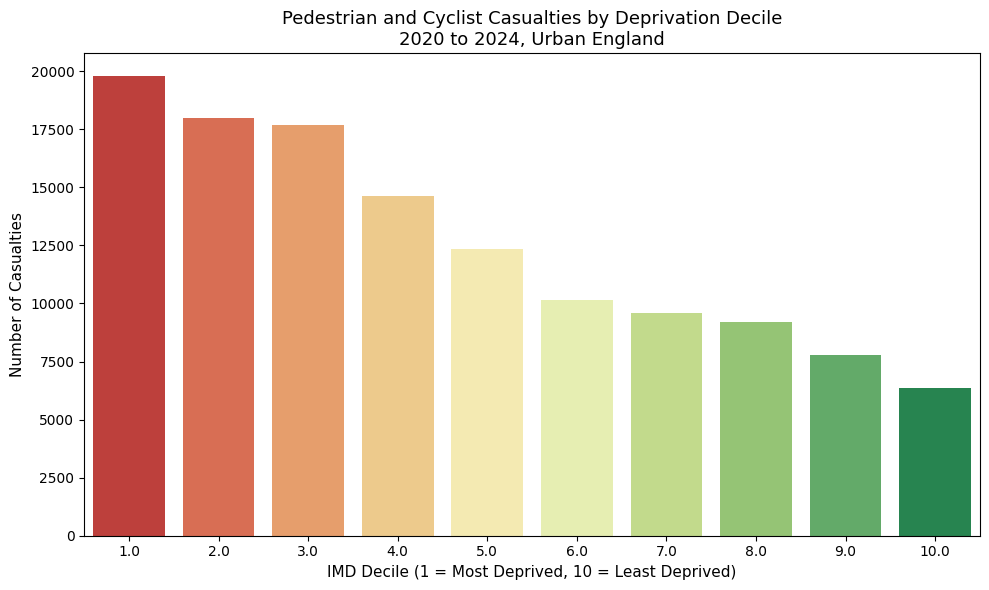

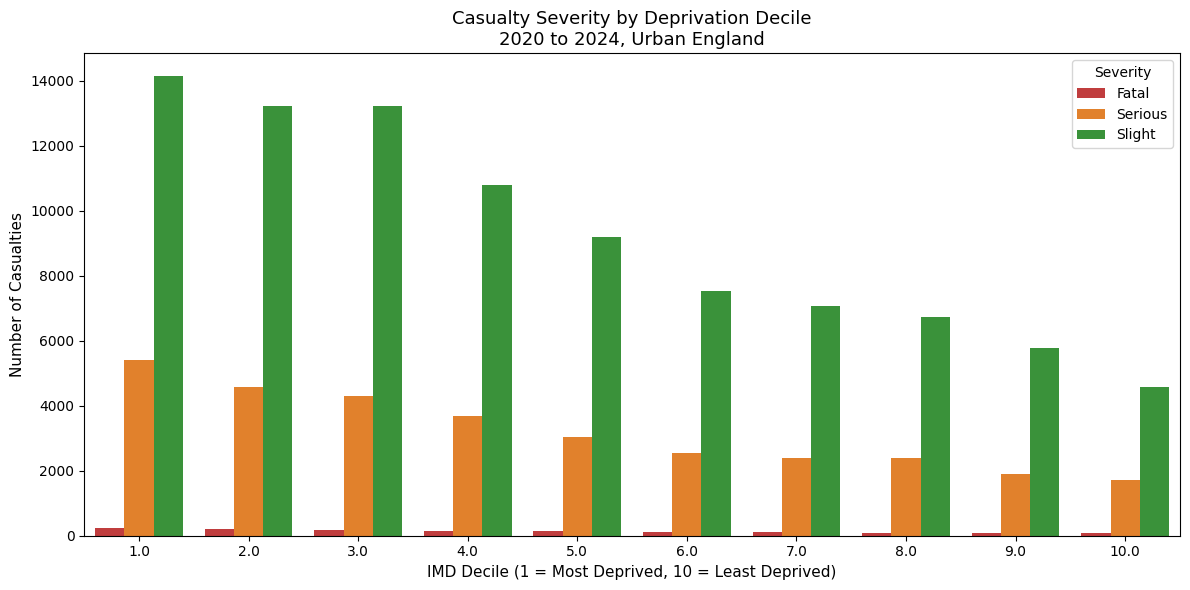

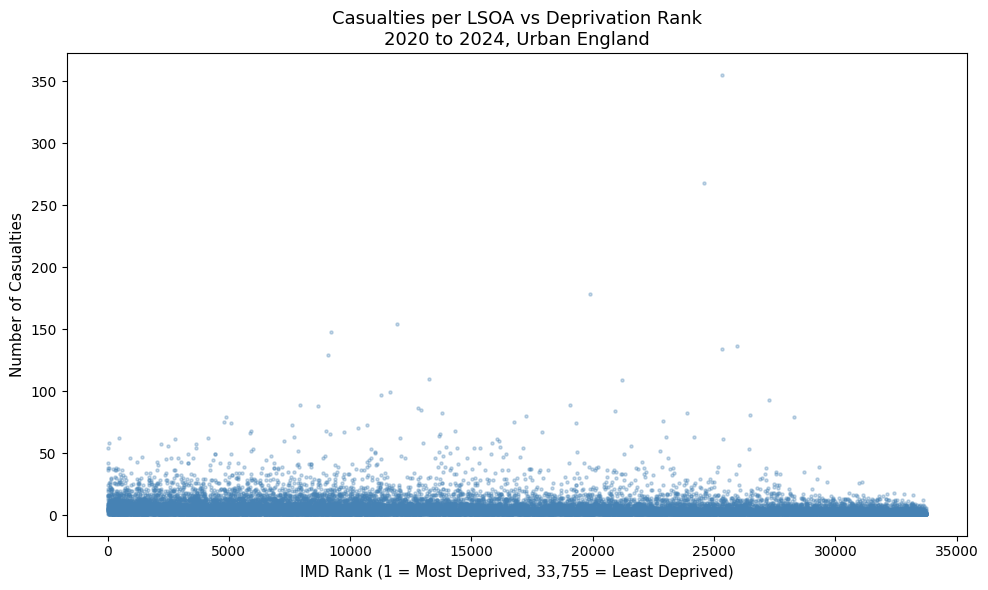

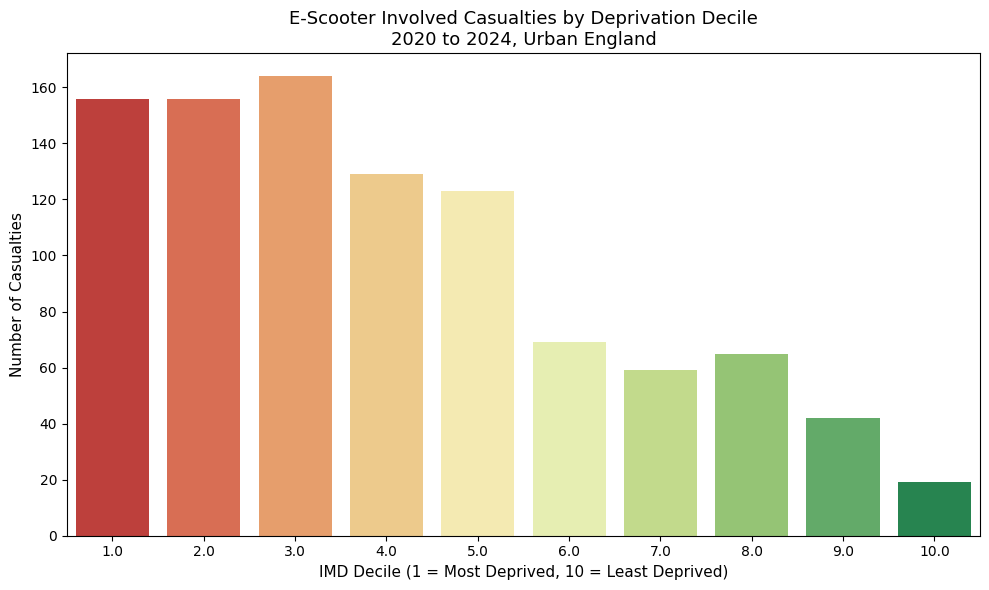

In [28]:
import os

FIGURES = "/Users/dhruvjani/2026projects/micromobility-safety-deprivation-uk/outputs/figures/"
os.makedirs(FIGURES, exist_ok=True)

# Fig 1 - Casualties by IMD Decile
decile_counts = master.groupby('imd_decile').size().reset_index(name='casualty_count')
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=decile_counts, x='imd_decile', y='casualty_count', palette='RdYlGn', ax=ax1)
ax1.set_title('Pedestrian and Cyclist Casualties by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
ax1.set_xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
ax1.set_ylabel('Number of Casualties', fontsize=11)
fig1.tight_layout()
fig1.savefig(FIGURES + "fig1_casualties_by_decile.png", dpi=150)
print("Saved fig1.")

# Fig 2 - Severity by IMD Decile
severity_decile = master.groupby(['imd_decile', 'severity_label']).size().reset_index(name='count')
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=severity_decile, x='imd_decile', y='count', hue='severity_label',
            palette={'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}, ax=ax2)
ax2.set_title('Casualty Severity by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
ax2.set_xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
ax2.set_ylabel('Number of Casualties', fontsize=11)
ax2.legend(title='Severity')
fig2.tight_layout()
fig2.savefig(FIGURES + "fig2_severity_by_decile.png", dpi=150)
print("Saved fig2.")

# Fig 3 - Scatter IMD Rank vs Casualties
lsoa_counts = master.groupby('lsoa_of_accident_location').agg(
    casualty_count=('collision_index', 'count'),
    imd_rank=('imd_rank', 'first')
).reset_index()
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.scatter(lsoa_counts['imd_rank'], lsoa_counts['casualty_count'], alpha=0.3, s=5, color='steelblue')
ax3.set_title('Casualties per LSOA vs Deprivation Rank\n2020 to 2024, Urban England', fontsize=13)
ax3.set_xlabel('IMD Rank (1 = Most Deprived, 33,755 = Least Deprived)', fontsize=11)
ax3.set_ylabel('Number of Casualties', fontsize=11)
fig3.tight_layout()
fig3.savefig(FIGURES + "fig3_scatter_imd_casualties.png", dpi=150)
print("Saved fig3.")

# Fig 4 - E-Scooter by Decile
escooter_only = master[master['escooter_flag'] == 1]
escooter_decile = escooter_only.groupby('imd_decile').size().reset_index(name='casualty_count')
fig4, ax4 = plt.subplots(figsize=(10, 6))
sns.barplot(data=escooter_decile, x='imd_decile', y='casualty_count', palette='RdYlGn', ax=ax4)
ax4.set_title('E-Scooter Involved Casualties by Deprivation Decile\n2020 to 2024, Urban England', fontsize=13)
ax4.set_xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=11)
ax4.set_ylabel('Number of Casualties', fontsize=11)
fig4.tight_layout()
fig4.savefig(FIGURES + "fig4_escooter_by_decile.png", dpi=150)
print("Saved fig4.")

print("\nAll figures saved to:", FIGURES)